#**K-NEAREST NEIGHBORS [ KNN ] :**

#**Libraries :**

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

#**DATASET LOADING :**

In [2]:
Dataset = load_iris()

In [3]:
Dataset

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [4]:
Dataset.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [5]:
X = Dataset.data
y = Dataset.target

#**CONVERT TO DATAFRAME :**

In [6]:
import pandas as pd
df = pd.DataFrame(X, columns=Dataset.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [7]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

#**SET TARGET :**

In [8]:
print(set(y))
Dataset.target_names

{np.int64(0), np.int64(1), np.int64(2)}


array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [9]:
df["target"]=y
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


#**SHAPE :**

In [10]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


#**TRAIN TEST SPLIT :**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

#**SCALER :**

In [14]:
Std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()

X_train_Std = Std_scaler.fit_transform(X_train)
X_train_mm = mm_scaler.fit_transform(X_train)

In [15]:
X_train_Std

array([[ 0.31553662, -0.04578885,  0.44767531,  0.23380268],
       [ 2.2449325 , -0.04578885,  1.29769171,  1.39742892],
       [-0.2873996 , -1.24028061,  0.05100098, -0.15407273],
       [ 0.67729835, -0.52358555,  1.01435291,  1.13884531],
       [-0.04622511, -0.52358555,  0.73101411,  1.52672073],
       [-0.64916132,  1.62649961, -1.30902526, -1.31769898],
       [-0.40798684, -1.71807731,  0.10766874,  0.10451088],
       [-0.76974857,  0.90980456, -1.36569302, -1.31769898],
       [ 0.79788559, -0.52358555,  0.44767531,  0.36309449],
       [ 1.03906007, -1.24028061,  1.12768843,  0.7509699 ],
       [ 1.15964732, -0.04578885,  0.95768515,  1.13884531],
       [-0.89033581,  1.14870291, -1.36569302, -1.18840717],
       [ 0.19494938, -1.95697567,  0.67434635,  0.36309449],
       [ 0.5567111 , -0.2846872 ,  1.01435291,  0.7509699 ],
       [ 0.91847283, -0.2846872 ,  0.44767531,  0.10451088],
       [ 2.2449325 , -1.00138226,  1.75103379,  1.39742892],
       [-0.16681235,  1.

In [16]:
X_train_mm

array([[0.52941176, 0.41666667, 0.61016949, 0.54166667],
       [1.        , 0.41666667, 0.86440678, 0.91666667],
       [0.38235294, 0.20833333, 0.49152542, 0.41666667],
       [0.61764706, 0.33333333, 0.77966102, 0.83333333],
       [0.44117647, 0.33333333, 0.69491525, 0.95833333],
       [0.29411765, 0.70833333, 0.08474576, 0.04166667],
       [0.35294118, 0.125     , 0.50847458, 0.5       ],
       [0.26470588, 0.58333333, 0.06779661, 0.04166667],
       [0.64705882, 0.33333333, 0.61016949, 0.58333333],
       [0.70588235, 0.20833333, 0.81355932, 0.70833333],
       [0.73529412, 0.41666667, 0.76271186, 0.83333333],
       [0.23529412, 0.625     , 0.06779661, 0.08333333],
       [0.5       , 0.08333333, 0.6779661 , 0.58333333],
       [0.58823529, 0.375     , 0.77966102, 0.70833333],
       [0.67647059, 0.375     , 0.61016949, 0.5       ],
       [1.        , 0.25      , 1.        , 0.91666667],
       [0.41176471, 0.75      , 0.11864407, 0.08333333],
       [0.20588235, 0.66666667,

In [29]:
X_test = Std_scaler.transform(X_test)
X_test

array([[-0.04622511,  2.34319467, -1.47902854, -1.31769898],
       [-0.89033581, -1.24028061, -0.45900886, -0.15407273],
       [ 0.91847283, -0.04578885,  0.33433978,  0.23380268],
       [-0.52857408,  2.10429632, -1.42236078, -1.05911537],
       [ 2.48610699,  1.86539796,  1.46769499,  1.00955351],
       [ 0.5567111 ,  0.6709062 ,  0.50434307,  0.49238629],
       [ 1.28023456,  0.1931095 ,  0.73101411,  1.39742892],
       [-0.89033581,  1.86539796, -1.08235422, -1.05911537],
       [-1.37268478,  0.43200785, -1.2523575 , -1.31769898],
       [ 1.28023456,  0.43200785,  1.07102067,  1.39742892],
       [-0.2873996 , -0.76248391,  0.22100426,  0.10451088],
       [-0.52857408,  2.10429632, -1.19568974, -1.05911537],
       [ 1.52140905, -0.04578885,  1.18435619,  1.13884531],
       [ 0.67729835,  0.43200785,  0.39100755,  0.36309449],
       [ 0.19494938, -0.2846872 ,  0.39100755,  0.36309449],
       [-1.73444651,  0.43200785, -1.42236078, -1.31769898],
       [-0.04622511, -1.

In [18]:
X_test = mm_scaler.transform(X_test)
X_test

array([[-1.16043622, -1.07710823, -0.07758329, -0.03239687],
       [-1.30384435, -0.14548441, -0.37919211, -0.53296574],
       [-0.58680371, -1.263433  ,  0.14359651,  0.57940952],
       [-1.19628825, -0.98394585, -0.09769055,  0.13445942],
       [-0.909472  , -1.07710823, -0.06752966,  0.07884065],
       [-1.41140045, -0.51813394, -0.39929936, -0.47734698],
       [-1.33969638, -0.98394585, -0.18817319,  0.02322189],
       [-0.87361997, -0.79762109, -0.03736878,  0.57940952],
       [-1.12458419, -1.63608253, -0.09769055,  0.13445942],
       [-1.26799232, -1.17027062, -0.15801231, -0.03239687],
       [-1.01702809, -0.7044587 , -0.03736878,  0.41255323],
       [-1.62651264, -0.89078347, -0.40935299, -0.64420327],
       [-1.37554841, -0.42497156, -0.41940662, -0.58858451],
       [-1.59066061, -0.79762109, -0.39929936, -0.64420327],
       [-1.51895654, -0.14548441, -0.39929936, -0.53296574],
       [-1.08873216, -0.61129632, -0.07758329,  0.19007818],
       [-1.01702809, -0.

In [17]:
Flowers = KNeighborsClassifier(n_neighbors=5)
Flowers.fit(X_train, y_train)

KNeighborsClassifier()

In [18]:
y_pred = Flowers.predict(X_test)

# **ACCURACY | CLASSIFICATION REPORT | CONFUSION MATRIX :**

In [21]:
print("ACCURACY = ", accuracy_score(y_test, y_pred))
print("\n\nCLASSIFICATION REPORT :\n\n", classification_report(y_test, y_pred))
print("\n\nCONFUSION MATRIX :\n\n", confusion_matrix(y_test, y_pred))

ACCURACY =  1.0


CLASSIFICATION REPORT :

               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



CONFUSION MATRIX :

 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]


In [22]:
print("ACCURACY = ", accuracy_score(y_test, y_pred))
print("\n\nCLASSIFICATION REPORT :\n\n", classification_report(y_test, y_pred))
print("\n\nCONFUSION MATRIX :\n\n", confusion_matrix(y_test, y_pred))

ACCURACY =  1.0


CLASSIFICATION REPORT :

               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



CONFUSION MATRIX :

 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]


#**VISUALIZATION USING HEATMAPS :**

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

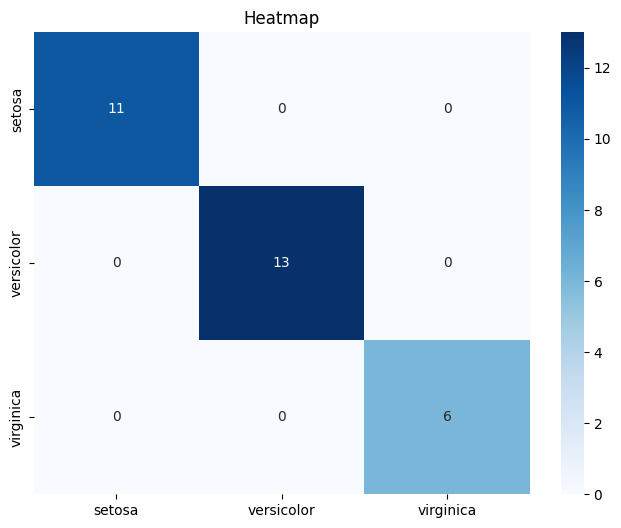

In [32]:
CFM = confusion_matrix(y_test, y_pred)
labels = Dataset.target_names

plt.figure(figsize=(8,6))
sns.heatmap(CFM,annot=True,fmt="d",xticklabels=labels,yticklabels=labels,cmap="Blues")
plt.title("Heatmap")
plt.show()